
# Better Quant Model – End-to-End Research Notebook
*

This notebook upgrades your original prototype into a **complete, research-grade workflow**:

- Robust **data ingestion** (multiple NSE tickers + NIFTY benchmark)
- **Feature engineering**: RSI, MACD, SMA/EMA, Bollinger Bands, Momentum, Volatility, ATR
- **Labels**: next-day direction and returns
- **Time-series cross-validation** with expanding windows
- **Modeling**: Weighted_EnsembleL2
- **Backtest**: long/flat per ticker with probability thresholds, daily rebalancing, transaction costs
- **Portfolio**: signal-weighted, risk-aware normalization
- **Evaluation**: CAGR, Sharpe, Max Drawdown, Hit Rate, Alpha/Beta vs NIFTY
- **Visuals** (matplotlib only): equity curve vs NIFTY, drawdown, rolling Sharpe, factor importances

In [2]:
pip install --upgrade pip

  Attempting uninstall: pip
    Found existing installation: pip 21.2.4
    Uninstalling pip-21.2.4:
      Successfully uninstalled pip-21.2.4
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install autogluon

  Using cached autogluon-1.4.0-py3-none-any.whl.metadata (11 kB)
  Using cached autogluon.tabular-1.4.0-py3-none-any.whl.metadata (16 kB)
  Using cached autogluon.multimodal-1.4.0-py3-none-any.whl.metadata (13 kB)
  Using cached autogluon.timeseries-1.4.0-py3-none-any.whl.metadata (12 kB)
  Using cached hyperopt-0.2.7-py2.py3-none-any.whl.metadata (1.7 kB)
  Using cached seqeval-1.2.2-py3-none-any.whl
  Using cached evaluate-0.4.5-py3-none-any.whl.metadata (9.5 kB)
  Using cached timm-1.0.3-py3-none-any.whl.metadata (43 kB)
  Using cached text_unidecode-1.3-py2.py3-none-any.whl.metadata (2.4 kB)
  Using cached omegaconf-2.3.0-py3-none-any.whl.metadata (3.9 kB)
  Using cached pytorch_metric_learning-2.8.1-py3-none-any.whl.metadata (18 kB)
  Using cached nlpaug-1.1.11-py3-none-any.whl.metadata (14 kB)
  Using cached openmim-0.3.9-py2.py3-none-any.whl.metadata (16 kB)
  Using cached pytesseract-0.3.13-py3-none-any.whl.metadata (11 kB)
  Using cached nvidia_ml_py3-7.352.0-py3-none-any.whl


ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\Nirvan\\Desktop\\venv\\Lib\\site-packages\\nltk\\cluster\\util.py'
Check the permissions.



In [6]:
import warnings, math, sys
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [9]:
plt.rcParams["figure.figsize"] = (10, 5)  # one chart per figure, no explicit colors


In [10]:
CONFIG = {
    "tickers": [
        "HDFCBANK.NS", "ICICIBANK.NS", "RELIANCE.NS",
        "TCS.NS", "INFY.NS"
    ],
    "benchmark": "^NSEI",                
    "start": "2017-01-01",
    "end": None,                         # None = today
    "rebalance_freq": "D",               # Daily
    "txn_cost_bps": 5,                   # 5 bps per trade (0.05% round-trip ~ 10 bps)
    "proba_entry": 0.55,                 # enter long if P(up) >= 0.55
    "proba_exit": 0.50,                  # exit to flat if P(up) < 0.50
    "risk_target_vol": 0.15,             # annualized target vol for scaling position (optional)
    "rolling_window_sharpe": 126,        # 6 months (21*6)
    "min_train_years": 3                 # minimal training horizon before first backtest step
}

CONFIG

{'tickers': ['HDFCBANK.NS',
  'ICICIBANK.NS',
  'RELIANCE.NS',
  'TCS.NS',
  'INFY.NS'],
 'benchmark': '^NSEI',
 'start': '2017-01-01',
 'end': None,
 'rebalance_freq': 'D',
 'txn_cost_bps': 5,
 'proba_entry': 0.55,
 'proba_exit': 0.5,
 'risk_target_vol': 0.15,
 'rolling_window_sharpe': 126,
 'min_train_years': 3}

In [11]:
def get_data(tickers, start, end):
    df = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        close = df["Close"].copy()
        openp = df["Open"].copy()
        high = df["High"].copy()
        low = df["Low"].copy()
    else:
        close = df["Close"].to_frame(tickers[0])
        openp = df["Open"].to_frame(tickers[0])
        high = df["High"].to_frame(tickers[0])
        low = df["Low"].to_frame(tickers[0])
    return openp, high, low, close

OPEN, HIGH, LOW, CLOSE = get_data(CONFIG["tickers"], CONFIG["start"], CONFIG["end"])
_, _, _, BMK_CLOSE = get_data([CONFIG["benchmark"]], CONFIG["start"], CONFIG["end"])
BMK_CLOSE = BMK_CLOSE.squeeze().dropna().rename("BENCH")

CLOSE.tail()


Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2025-08-18,2003.599976,1434.599976,1435.800049,1381.699951,3011.199951
2025-08-19,1991.099976,1436.300049,1440.000000,1420.099976,3016.199951
2025-08-20,1988.199951,1430.599976,1496.199951,1413.000000,3098.600098
2025-08-21,1991.199951,1446.000000,1496.400024,1424.800049,3102.600098
2025-08-22,1964.599976,1436.400024,1487.500000,1409.199951,3054.000000


In [12]:
def sma(s, n): return s.rolling(n).mean()
def ema(s, n): return s.ewm(span=n, adjust=False).mean()

def rsi(series, n=14):
    delta = series.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.ewm(alpha=1/n, adjust=False).mean()
    roll_down = down.ewm(alpha=1/n, adjust=False).mean()
    rs = roll_up / (roll_down + 1e-12)
    return 100 - (100 / (1 + rs))

def macd(series, fast=12, slow=26, signal=9):
    macd_line = ema(series, fast) - ema(series, slow)
    signal_line = ema(macd_line, signal)
    hist = macd_line - signal_line
    return macd_line, signal_line, hist

def bbands(series, n=20, k=2):
    mid = sma(series, n)
    std = series.rolling(n).std()
    upper = mid + k*std
    lower = mid - k*std
    width = (upper - lower) / mid
    return upper, mid, lower, width

def atr(high, low, close, n=14):
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low),
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(n).mean()

def build_features(OPEN, HIGH, LOW, CLOSE):
    feats = {}
    for t in CLOSE.columns:
        px = CLOSE[t].dropna()
        op = OPEN[t].reindex(px.index)
        hi = HIGH[t].reindex(px.index)
        lo = LOW[t].reindex(px.index)

        df = pd.DataFrame(index=px.index)
        df["close"] = px
        df["ret1"] = px.pct_change()
        df["ret5"] = px.pct_change(5)
        df["ret21"] = px.pct_change(21)



In [15]:
def sma(s, n): return s.rolling(n).mean()
def ema(s, n): return s.ewm(span=n, adjust=False).mean()

def rsi(series, n=14):
    delta = series.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.ewm(alpha=1/n, adjust=False).mean()
    roll_down = down.ewm(alpha=1/n, adjust=False).mean()
    rs = roll_up / (roll_down + 1e-12)
    return 100 - (100 / (1 + rs))

def macd(series, fast=12, slow=26, signal=9):
    macd_line = ema(series, fast) - ema(series, slow)
    signal_line = ema(macd_line, signal)
    hist = macd_line - signal_line
    return macd_line, signal_line, hist

def bbands(series, n=20, k=2):
    mid = sma(series, n)
    std = series.rolling(n).std()
    upper = mid + k*std
    lower = mid - k*std
    width = (upper - lower) / mid
    return upper, mid, lower, width

def atr(high, low, close, n=14):
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low),
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(n).mean()

def build_features(OPEN, HIGH, LOW, CLOSE):
    feats = {}
    for t in CLOSE.columns:
        px = CLOSE[t].dropna()
        op = OPEN[t].reindex(px.index)
        hi = HIGH[t].reindex(px.index)
        lo = LOW[t].reindex(px.index)

        df = pd.DataFrame(index=px.index)
        df["close"] = px
        df["ret1"] = px.pct_change()
        df["ret5"] = px.pct_change(5)
        df["ret21"] = px.pct_change(21)

        # MAs
        for n in [5, 10, 20, 50, 100, 200]:
            df[f"sma_{n}"] = sma(px, n) / px - 1
            df[f"ema_{n}"] = ema(px, n) / px - 1

        # RSI & MACD
        df["rsi_14"] = rsi(px, 14)
        macd_line, signal_line, hist = macd(px)
        df["macd"] = macd_line
        df["macd_signal"] = signal_line
        df["macd_hist"] = hist

        # Bollinger
        ub, mid, lb, w = bbands(px, 20, 2)
        df["bb_width"] = w
        df["bb_pos"] = (px - mid) / (ub - lb + 1e-12)

        # ATR (volatility proxy)
        df["atr14"] = atr(hi, lo, px, 14) / px

        # Momentum spillovers
        df["mom_5"] = (px / px.shift(5) - 1)
        df["mom_21"] = (px / px.shift(21) - 1)

        # Next-day label
        df["fwd_ret1"] = df["ret1"].shift(-1)
        df["y_up"] = (df["fwd_ret1"] > 0).astype(int)

        feats[t] = df.dropna().copy()
    return feats

FEATS = build_features(OPEN, HIGH, LOW, CLOSE)
list(FEATS.keys())[:5], FEATS[CONFIG["tickers"][0]].head()


(['HDFCBANK.NS', 'ICICIBANK.NS', 'INFY.NS', 'RELIANCE.NS', 'TCS.NS'],
                  close      ret1      ret5     ret21     sma_5     ema_5  \
 Date                                                                       
 2017-10-23  873.588074  0.008061  0.006754  0.007816 -0.002995 -0.005302   
 2017-10-24  875.369690  0.002039  0.005358  0.015225 -0.003958 -0.004885   
 2017-10-25  841.613220 -0.038563 -0.030331 -0.015898  0.029737  0.023353   
 2017-10-26  841.730469  0.000139 -0.039149 -0.002445  0.021444  0.015473   
 2017-10-27  839.714417 -0.002395 -0.031027 -0.000697  0.017493  0.011941   
 
               sma_10    ema_10    sma_20    ema_20  ...      macd  \
 Date                                                ...             
 2017-10-23 -0.015373 -0.011825 -0.024721 -0.019187  ...  7.588248   
 2017-10-24 -0.013542 -0.011321 -0.025554 -0.019166  ...  8.126039   
 2017-10-25  0.025600  0.023183  0.013400  0.018253  ...  5.761957   
 2017-10-26  0.025747  0.018851  0.0133

In [16]:
from autogluon.tabular import TabularPredictor

In [18]:
def assemble_tabular(FEATS):
    frames = []
    for t, df in FEATS.items():
        tmp = df.copy()
        tmp["date"] = tmp.index
        tmp["ticker"] = t
        # Keep features + label only (drop price and fwd return targets)
        keep_cols = [c for c in tmp.columns if c not in ["close", "fwd_ret1"]]
        frames.append(tmp[keep_cols])
    all_df = pd.concat(frames, axis=0).sort_values(["date", "ticker"]).reset_index(drop=True)
    return all_df

tab = assemble_tabular(FEATS)
print("Tabular shape:", tab.shape)
display(tab.head())
label = "y_up"
cutoff = tab["date"].max() - pd.Timedelta(days=180)
train_df = tab[tab["date"] < cutoff].copy()
test_df  = tab[tab["date"] >= cutoff].copy()
features = [c for c in train_df.columns if c not in [label, "date", "ticker"]]

print("Train:", train_df.shape, "Test:", test_df.shape)

Tabular shape: (9680, 27)


,ret1,ret5,ret21,sma_5,ema_5,sma_10,ema_10,sma_20,ema_20,sma_50,...,macd_signal,macd_hist,bb_width,bb_pos,atr14,mom_5,mom_21,y_up,date,ticker
0,0.008061,0.006754,0.007816,-0.002995,-0.005302,-0.015373,-0.011825,-0.024721,-0.019187,-0.034744,...,5.356968,2.231279,0.062639,0.404661,0.013235,0.006754,0.007816,1,2017-10-23,HDFCBANK.NS
1,0.018228,-0.032252,-0.096369,0.014435,0.007408,0.020644,0.019382,0.037183,0.038530,0.086540,...,-5.580475,-0.581992,0.091104,-0.393508,0.022009,-0.032252,-0.096369,1,2017-10-23,ICICIBANK.NS
2,0.013539,0.010107,0.029363,-0.007919,-0.008128,-0.009287,-0.012357,-0.024516,-0.018808,-0.022445,...,1.222712,1.093485,0.069606,0.361062,0.012085,0.010107,0.029363,0,2017-10-23,INFY.NS
3,0.032806,0.072223,0.109308,-0.039042,-0.033986,-0.065869,-0.058280,-0.101758,-0.083920,-0.125542,...,7.296981,4.388324,0.208539,0.543237,0.025071,0.072223,0.109308,0,2017-10-23,RELIANCE.NS
4,0.001549,0.011452,0.037838,-0.000166,-0.003896,-0.016274,-0.013282,-0.031623,-0.023935,-0.035704,...,6.893106,5.759102,0.094329,0.346194,0.015415,0.011452,0.037838,0,2017-10-23,TCS.NS


Train: (9075, 27) Test: (605, 27)


In [ ]:
# (Optional) Install if needed:
# %pip install -U pip
# %pip install autogluon.tabular

import pandas as pd
import numpy as np
from pathlib import Path   


def assemble_tabular(FEATS):
    frames = []
    for t, df in FEATS.items():
        tmp = df.copy()
        tmp["date"] = tmp.index
        tmp["ticker"] = t
        keep_cols = [c for c in tmp.columns if c not in ["close", "fwd_ret1"]]
        frames.append(tmp[keep_cols])
    all_df = pd.concat(frames, axis=0).sort_values(["date", "ticker"]).reset_index(drop=True)
    return all_df

tab = assemble_tabular(FEATS)
print("Tabular shape:", tab.shape)
display(tab.head())

# 12.2) Time-based split (last ~6 months as test)
label = "y_up"
cutoff = tab["date"].max() - pd.Timedelta(days=180)
train_df = tab[tab["date"] < cutoff].copy()
test_df  = tab[tab["date"] >= cutoff].copy()
features = [c for c in train_df.columns if c not in [label, "date", "ticker"]]

print("Train:", train_df.shape, "Test:", test_df.shape)

# 12.3) Train AutoGluon Tabular
try:
    from autogluon.tabular import TabularPredictor

    out_dir = Path("autogluon_tabular")
    out_dir.mkdir(exist_ok=True)

    predictor = TabularPredictor(
        label=label,
        problem_type="binary",
        path=str(out_dir)
    ).fit(
        train_data=train_df[features + [label]],
        time_limit=600,
        presets="medium_quality"
    )
    print("Training complete. Models saved to:", out_dir)


    lb = predictor.leaderboard(test_df[features + [label]], silent=True)
    lb.to_csv("autogluon_leaderboard.csv", index=False)
    display(lb)

    # 12.5) Accuracy on test
    preds = predictor.predict(test_df[features])
    acc = (preds.values == test_df[label].values).mean()
    print(f"Test Accuracy: {acc:.4f}")

except Exception as e:
    print("AutoGluon not available or training failed. Install it and re-run.")
    print("Error:", e)


Tabular shape: (9680, 27)


,ret1,ret5,ret21,sma_5,ema_5,sma_10,ema_10,sma_20,ema_20,sma_50,...,macd_signal,macd_hist,bb_width,bb_pos,atr14,mom_5,mom_21,y_up,date,ticker
0,0.008061,0.006754,0.007816,-0.002995,-0.005302,-0.015373,-0.011825,-0.024721,-0.019187,-0.034744,...,5.356968,2.231279,0.062639,0.404661,0.013235,0.006754,0.007816,1,2017-10-23,HDFCBANK.NS
1,0.018228,-0.032252,-0.096369,0.014435,0.007408,0.020644,0.019382,0.037183,0.038530,0.086540,...,-5.580475,-0.581992,0.091104,-0.393508,0.022009,-0.032252,-0.096369,1,2017-10-23,ICICIBANK.NS
2,0.013539,0.010107,0.029363,-0.007919,-0.008128,-0.009287,-0.012357,-0.024516,-0.018808,-0.022445,...,1.222712,1.093485,0.069606,0.361062,0.012085,0.010107,0.029363,0,2017-10-23,INFY.NS
3,0.032806,0.072223,0.109308,-0.039042,-0.033986,-0.065869,-0.058280,-0.101758,-0.083920,-0.125542,...,7.296981,4.388324,0.208539,0.543237,0.025071,0.072223,0.109308,0,2017-10-23,RELIANCE.NS
4,0.001549,0.011452,0.037838,-0.000166,-0.003896,-0.016274,-0.013282,-0.031623,-0.023935,-0.035704,...,6.893106,5.759102,0.094329,0.346194,0.015415,0.011452,0.037838,0,2017-10-23,TCS.NS


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.9.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          16
Memory Avail:       1.41 GB / 15.26 GB (9.2%)
Disk Space Avail:   159.69 GB / 930.62 GB (17.2%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'


Train: (9075, 27) Test: (605, 27)


Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "c:\Users\Nirvan\Desktop\Karyaneeti\autogluon_tabular"
Train Data Rows:    9075
Train Data Columns: 24
Label Column:       y_up
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    1359.73 MB
	Train Data (Original)  Memory Usage: 1.66 MB (0.1% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Unused Original Features (C

Training complete. Models saved to: autogluon_tabular


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetFastAI,0.509091,0.546256,accuracy,0.059888,0.017499,6.810745,0.059888,0.017499,6.810745,1,True,8
1,WeightedEnsemble_L2,0.499174,0.557269,accuracy,0.147706,0.026544,11.615554,0.013540,0.000999,0.053201,2,True,12
2,CatBoost,0.492562,0.540749,accuracy,0.029130,0.002518,3.503580,0.029130,0.002518,3.503580,1,True,5
3,NeuralNetTorch,0.489256,0.533040,accuracy,0.037592,0.013045,12.033217,0.037592,0.013045,12.033217,1,True,10
4,LightGBMLarge,0.485950,0.541850,accuracy,0.019058,0.004514,1.184506,0.019058,0.004514,1.184506,1,True,11
5,RandomForestEntr,0.485950,0.527533,accuracy,0.168621,0.061523,2.359189,0.168621,0.061523,2.359189,1,True,4
6,RandomForestGini,0.485950,0.520925,accuracy,0.192506,0.062537,1.813411,0.192506,0.062537,1.813411,1,True,3
7,LightGBMXT,0.484298,0.545154,accuracy,0.021508,0.006407,6.012125,0.021508,0.006407,6.012125,1,True,1
8,LightGBM,0.482645,0.533040,accuracy,0.026087,0.006649,0.669104,0.026087,0.006649,0.669104,1,True,2
9,ExtraTreesEntr,0.482645,0.520925,accuracy,0.204105,0.062181,0.698761,0.204105,0.062181,0.698761,1,True,7


Test Accuracy: 0.4992


In [27]:
%pip install -U pip
%pip install autogluon.tabular

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [43]:
predictor=TabularPredictor.load("autogluon_tabular")
lb = predictor.leaderboard(test_df[features + [label]], silent=True)
display(lb)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetFastAI,0.509091,0.546256,accuracy,0.032113,0.017499,6.810745,0.032113,0.017499,6.810745,1,True,8
1,WeightedEnsemble_L2,0.499174,0.557269,accuracy,0.074188,0.026544,11.615554,0.003015,0.000999,0.053201,2,True,12
2,CatBoost,0.492562,0.540749,accuracy,0.016190,0.002518,3.503580,0.016190,0.002518,3.503580,1,True,5
3,NeuralNetTorch,0.489256,0.533040,accuracy,0.018053,0.013045,12.033217,0.018053,0.013045,12.033217,1,True,10
4,LightGBMLarge,0.485950,0.541850,accuracy,0.007015,0.004514,1.184506,0.007015,0.004514,1.184506,1,True,11
5,RandomForestEntr,0.485950,0.527533,accuracy,0.155016,0.061523,2.359189,0.155016,0.061523,2.359189,1,True,4
6,RandomForestGini,0.485950,0.520925,accuracy,0.169051,0.062537,1.813411,0.169051,0.062537,1.813411,1,True,3
7,LightGBMXT,0.484298,0.545154,accuracy,0.013542,0.006407,6.012125,0.013542,0.006407,6.012125,1,True,1
8,LightGBM,0.482645,0.533040,accuracy,0.016097,0.006649,0.669104,0.016097,0.006649,0.669104,1,True,2
9,ExtraTreesEntr,0.482645,0.520925,accuracy,0.184372,0.062181,0.698761,0.184372,0.062181,0.698761,1,True,7


In [44]:
best_model = lb.sort_values("score_val", ascending=False).iloc[0]["model"]
print("Best model selected:", best_model)

Best model selected: WeightedEnsemble_L2


In [47]:
try:
    refit_map = predictor.refit_full(models=[chosen_model])
    chosen_model_full = refit_map.get(chosen_model, chosen_model)
    print("Refit done. Using model:", chosen_model_full)
except Exception as e:
    print("refit_full not available or failed -> using original model.", e)
    chosen_model_full = chosen_model

Refitting models via `predictor.refit_full` using all of the data (combined train and validation)...
	Models trained in this way will have the suffix "_FULL" and have NaN validation score.
	This process is not bound by time_limit, but should take less time than the original `predictor.fit` call.
	To learn more, refer to the `.refit_full` method docstring which explains how "_FULL" models differ from normal models.


refit_full not available or failed -> using original model. autogluon.tabular.trainer.abstract_trainer.AbstractTabularTrainer.refit_single_full() got multiple values for keyword argument 'models'


In [46]:
chosen_model = "WeightedEnsemble_L2"

In [49]:
proba_raw = predictor.predict_proba(test_df[features], model=chosen_model_full)


In [54]:
if isinstance(proba_raw, pd.DataFrame):
    # Try to pick column labeled 1 (or '1'); else pick the last column as positive
    if 1 in proba_raw.columns:
        proba_up = proba_raw[1]
    elif "1" in proba_raw.columns:
        proba_up = proba_raw["1"]
    else:
        # fallback: use the last column as positive class
        proba_up = proba_raw.iloc[:, -1]
    proba_up = proba_up.astype(float)
    

In [56]:
pred_up = (proba_up >= 0.5).astype(int)
test_pred = test_df[["date", "ticker", label]].copy()
test_pred["proba_up"] = proba_up.values
test_pred["pred_up"]  = pred_up.values
test_pred = test_pred.sort_values(["date","ticker"]).reset_index(drop=True)

In [57]:
p_enter = CONFIG.get("proba_entry", 0.55)
p_exit  = CONFIG.get("proba_exit", 0.50)

In [59]:
def positions_from_proba(df_t, p_enter, p_exit):
    pos, prev = [], 0.0
    for p in df_t["proba_up"]:
        if p >= p_enter: prev = 1.0
        elif p < p_exit: prev = 0.0
        pos.append(prev)
    return pd.Series(pos, index=df_t.index, name="pos")
test_pred["pos"] = test_pred.groupby("ticker", group_keys=False)\
                            .apply(lambda d: positions_from_proba(d, p_enter, p_exit))


In [60]:
frames = []
for t, df in FEATS.items():
    tmp = df[["fwd_ret1"]].copy()
    tmp["ticker"] = t
    tmp["date"] = tmp.index
    frames.append(tmp.reset_index(drop=True))

rets_all = pd.concat(frames, axis=0)
rets_all = rets_all.merge(test_pred[["date","ticker"]].drop_duplicates(),
                          on=["date","ticker"], how="inner")

bt = test_pred.merge(rets_all[["date","ticker","fwd_ret1"]],
                     on=["date","ticker"], how="left").sort_values(["date","ticker"])

cost_bps = CONFIG.get("txn_cost_bps", 5) / 10000.0

In [61]:
def pnl_with_costs(df_t):
    df_t = df_t.sort_values("date").copy()
    df_t["pos_prev"] = df_t["pos"].shift(1).fillna(0.0)
    df_t["turnover"] = (df_t["pos"] - df_t["pos_prev"]).abs()
    df_t["cost"] = df_t["turnover"] * cost_bps
    df_t["ret"] = df_t["pos"] * df_t["fwd_ret1"].fillna(0.0) - df_t["cost"]
    return df_t

bt = bt.groupby("ticker", group_keys=False).apply(pnl_with_costs)

In [62]:
pnl_df = bt.pivot_table(index="date", columns="ticker", values="ret").sort_index().fillna(0.0)
pos_wide = bt.pivot_table(index="date", columns="ticker", values="pos")\
            .reindex(pnl_df.index).fillna(0.0)

weights = pos_wide.div(pos_wide.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
port_ret = (pnl_df * weights).sum(axis=1)

In [79]:
def perf_stats(returns, freq=252):
    r = returns.dropna()
    if len(r)==0:
        return {"CAGR":np.nan,"Vol":np.nan,"Sharpe":np.nan,"MaxDD":np.nan,"HitRate":np.nan,"N":0}
    cagr  = (1+r).prod()**(freq/len(r)) - 1
    vol   = r.std()*np.sqrt(freq)
    sharpe= (r.mean()*freq)/(vol+1e-12)
    eq    = (1+r).cumprod()
    dd    = eq/eq.cummax() - 1
    mdd   = dd.min()
    hit   = (r>0).mean()
    return {
        "CAGR":   cagr,
        "Vol":    vol,
        "Sharpe": sharpe,
        "MaxDD":  mdd,
        "HitRate":hit,
        "N":      len(r)
    }

stats = perf_stats(port_ret)
print({k:(None if v is None else (f"{v:.4f}" if isinstance(v,float) else v)) for k,v in stats.items()})

{'CAGR': '0.1472', 'Vol': '0.1609', 'Sharpe': '0.9335', 'MaxDD': '-0.0760', 'HitRate': '0.4876', 'N': 121}


In [64]:
bmk = BMK_CLOSE.reindex(port_ret.index).ffill()
bmk_ret = bmk.pct_change().fillna(0.0)
eq_port = (1+port_ret).cumprod()
eq_bmk  = (1+bmk_ret).cumprod()

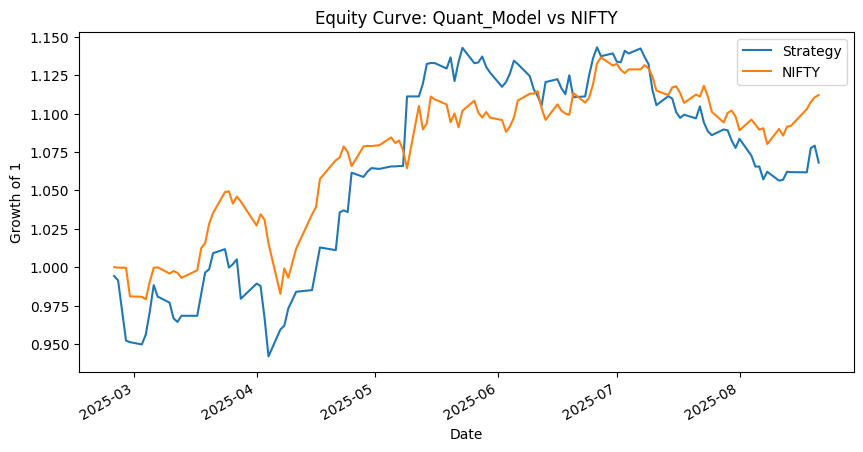

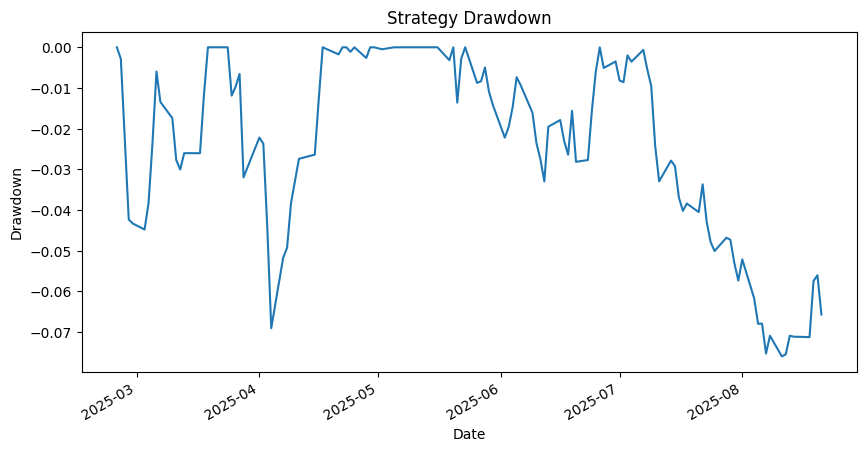

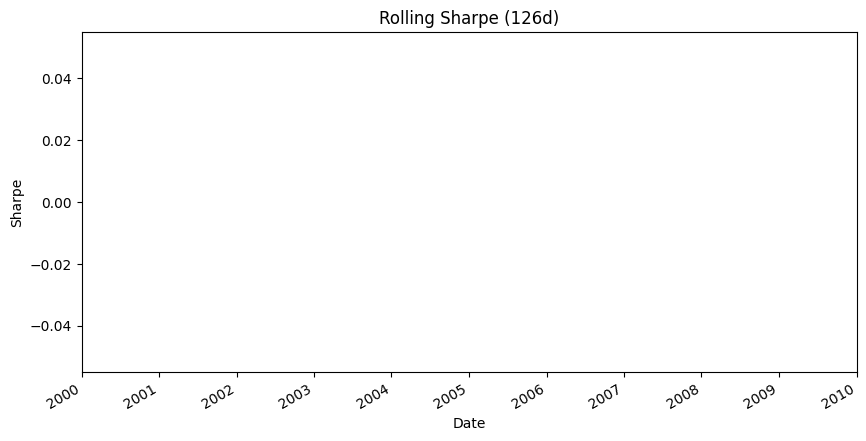

In [66]:
plt.figure()
eq_port.plot(label="Strategy")
eq_bmk.plot(label="NIFTY")
plt.title("Equity Curve: Quant_Model vs NIFTY")
plt.xlabel("Date"); plt.ylabel("Growth of 1"); plt.legend()

plt.figure()
(eq_port/eq_port.cummax()-1).plot()
plt.title("Strategy Drawdown")
plt.xlabel("Date"); plt.ylabel("Drawdown")

window = CONFIG.get("rolling_window_sharpe", 126)
plt.figure()
roll = port_ret.rolling(window=window)
((roll.mean()*252)/(roll.std()*np.sqrt(252)+1e-12)).plot()
plt.title(f"Rolling Sharpe ({window}d)")
plt.xlabel("Date"); plt.ylabel("Sharpe")
plt.show()

In [81]:
##from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
#from sklearn.preprocessing import StandardScaler
#from sklearn.linear_model import LinearRegression

